# 1. Perkenalan Dataset

**Nama:** Ahmad Fauzul Adhim  
**Dataset:** Heart Failure Prediction Dataset  
**URL Sumber:** [Kaggle Heart Failure Prediction](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction)


**Deskripsi Dataset:**

Dataset Heart Failure Prediction merupakan kumpulan data klinis pasien yang digabungkan dari 5 dataset jantung independen (Cleveland, Hungarian, Switzerland, Long Beach VA, dan Stalog). Dataset ini berisi **918 instance** dengan **11 fitur klinis** dan 1 label kelas biner.

**Fitur-fitur dataset:**
| Fitur | Deskripsi | Tipe |
|-------|-----------|------|
| `Age` | Usia pasien (tahun) | Numerik |
| `Sex` | Jenis kelamin (M=Pria, F=Wanita) | Kategorikal |
| `ChestPainType` | Tipe nyeri dada (TA, ATA, NAP, ASY) | Kategorikal |
| `RestingBP` | Tekanan darah saat istirahat (mm Hg) | Numerik |
| `Cholesterol` | Kolesterol serum (mg/dl) | Numerik |
| `FastingBS` | Gula darah puasa > 120 mg/dl (1=Ya, 0=Tidak) | Kategorikal |
| `RestingECG` | Hasil EKG saat istirahat (Normal, ST, LVH) | Kategorikal |
| `MaxHR` | Detak jantung maksimum yang dicapai | Numerik |
| `ExerciseAngina` | Angina akibat olahraga (Y=Ya, N=Tidak) | Kategorikal |
| `Oldpeak` | Depresi ST akibat olahraga relatif terhadap istirahat | Numerik |
| `ST_Slope` | Kemiringan segmen ST puncak saat olahraga (Up, Flat, Down) | Kategorikal |

**Target:** Kolom `HeartDisease` — nilai 0 menunjukkan tidak ada penyakit jantung, nilai 1 menunjukkan adanya penyakit jantung.

**Tantangan utama:**
- Fitur kategorikal bertipe string memerlukan encoding sebelum digunakan pada model.
- Terdapat potensi class imbalance antara pasien sehat dan sakit.
- Campuran fitur numerik dan kategorikal memerlukan preprocessing yang berbeda.


# 2. Import Library

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
print("Library Berhasil Di Import")

Library Berhasil Di Import


# 3. Memuat Dataset

In [2]:
df = pd.read_csv("data.csv", encoding="latin1", nrows=50000)
print(df.head())
df.info()
df.describe(include = "all")

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age    

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918,918,918.000000,918.000000,918.000000,918,918.000000,918,918.000000,918,918.000000
unique,NaN,2,4,NaN,NaN,NaN,3,NaN,2,NaN,3,NaN
top,NaN,M,ASY,NaN,NaN,NaN,Normal,NaN,N,NaN,Flat,NaN
freq,NaN,725,496,NaN,NaN,NaN,552,NaN,547,NaN,460,NaN
mean,53.510893,NaN,NaN,132.396514,198.799564,0.233115,NaN,136.809368,NaN,0.887364,NaN,0.553377
std,9.432617,NaN,NaN,18.514154,109.384145,0.423046,NaN,25.460334,NaN,1.066570,NaN,0.497414
min,28.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,60.000000,NaN,-2.600000,NaN,0.000000
25%,47.000000,NaN,NaN,120.000000,173.250000,0.000000,NaN,120.000000,NaN,0.000000,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,223.000000,0.000000,NaN,138.000000,NaN,0.600000,NaN,1.000000
75%,60.000000,NaN,NaN,140.000000,267.000000,0.000000,NaN,156.000000,NaN,1.500000,NaN,1.000000


In [3]:
# Check Missing Value
print("Missing Values")
print(df.isnull().sum())

# Check Duplicated Data 
print("Duplicate Data")
print(f"Jumlah Baris Yang duplikat : {(df.duplicated().sum())}")

# Check Shape
print("Ukuran Data")
print(f"Baris : {df.shape[0]}, Kolom : {df.shape[1]}")

Missing Values
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64
Duplicate Data
Jumlah Baris Yang duplikat : 0
Ukuran Data
Baris : 918, Kolom : 12


# 4. EDA Visualisasi Raw Data

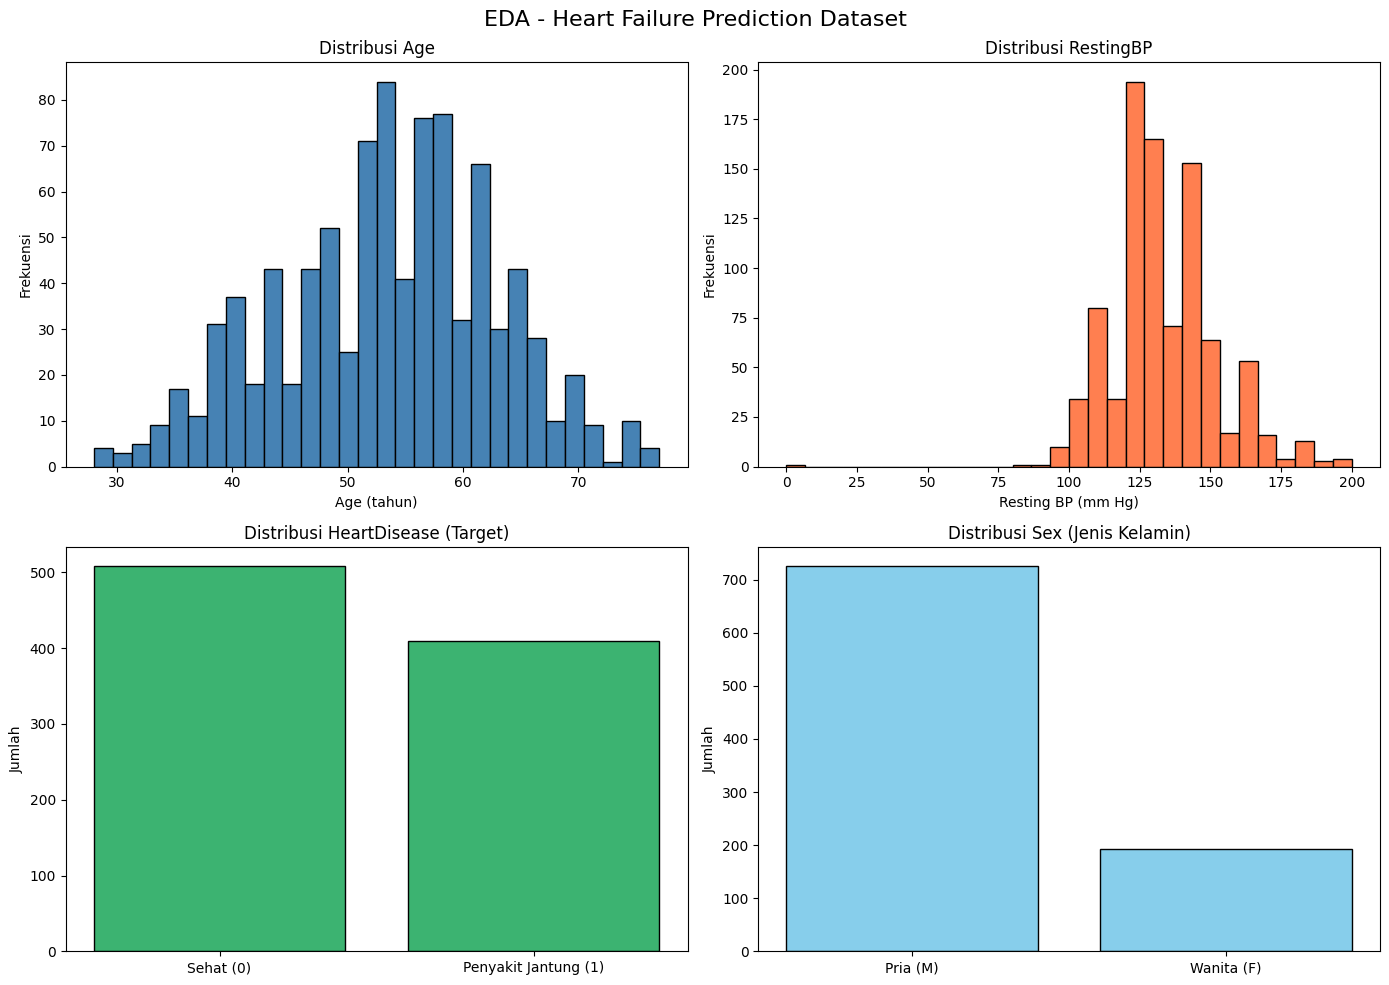

Visualisasi Berhasil & Disimpan


In [4]:
# EDA Visualisasi Raw Data

fig, axes = plt.subplots(2, 2, figsize = (14, 10))
fig.suptitle("EDA - Heart Failure Prediction Dataset", fontsize = 16)

# 1. Distribusi Age
# Untuk melihat sebaran usia pasien
axes[0,0].hist(df['Age'], bins = 30, color = 'steelblue', edgecolor= 'black')
axes[0,0].set_title('Distribusi Age')
axes[0,0].set_xlabel('Age (tahun)')
axes[0,0].set_ylabel('Frekuensi')

# 2. Distribusi RestingBP (Tekanan Darah)
# Untuk melihat range tekanan darah saat istirahat
axes[0,1].hist(df['RestingBP'].clip(0, 250), bins = 30, color = 'coral', edgecolor = 'black')
axes[0,1].set_title('Distribusi RestingBP')
axes[0,1].set_xlabel("Resting BP (mm Hg)")
axes[0,1].set_ylabel("Frekuensi")

# 3. Distribusi HeartDisease (Target Variable)
# Untuk melihat class distribution (sehat vs penyakit jantung)
disease_counts = df['HeartDisease'].value_counts()
axes[1,0].bar(['Sehat (0)', 'Penyakit Jantung (1)'], disease_counts.values, color = 'mediumseagreen', edgecolor='black')
axes[1,0].set_title('Distribusi HeartDisease (Target)')
axes[1,0].set_ylabel('Jumlah')

# 4. Distribusi Sex (Jenis Kelamin)
# Untuk melihat proporsi pria dan wanita
sex_counts = df['Sex'].value_counts()
axes[1,1].bar(['Pria (M)', 'Wanita (F)'], sex_counts.values, color= 'skyblue', edgecolor='black')
axes[1,1].set_title('Distribusi Sex (Jenis Kelamin)')
axes[1,1].set_ylabel('Jumlah')

plt.tight_layout()
plt.savefig('EDA_RawData_Visualization.png')
plt.show()
print("Visualisasi Berhasil & Disimpan")

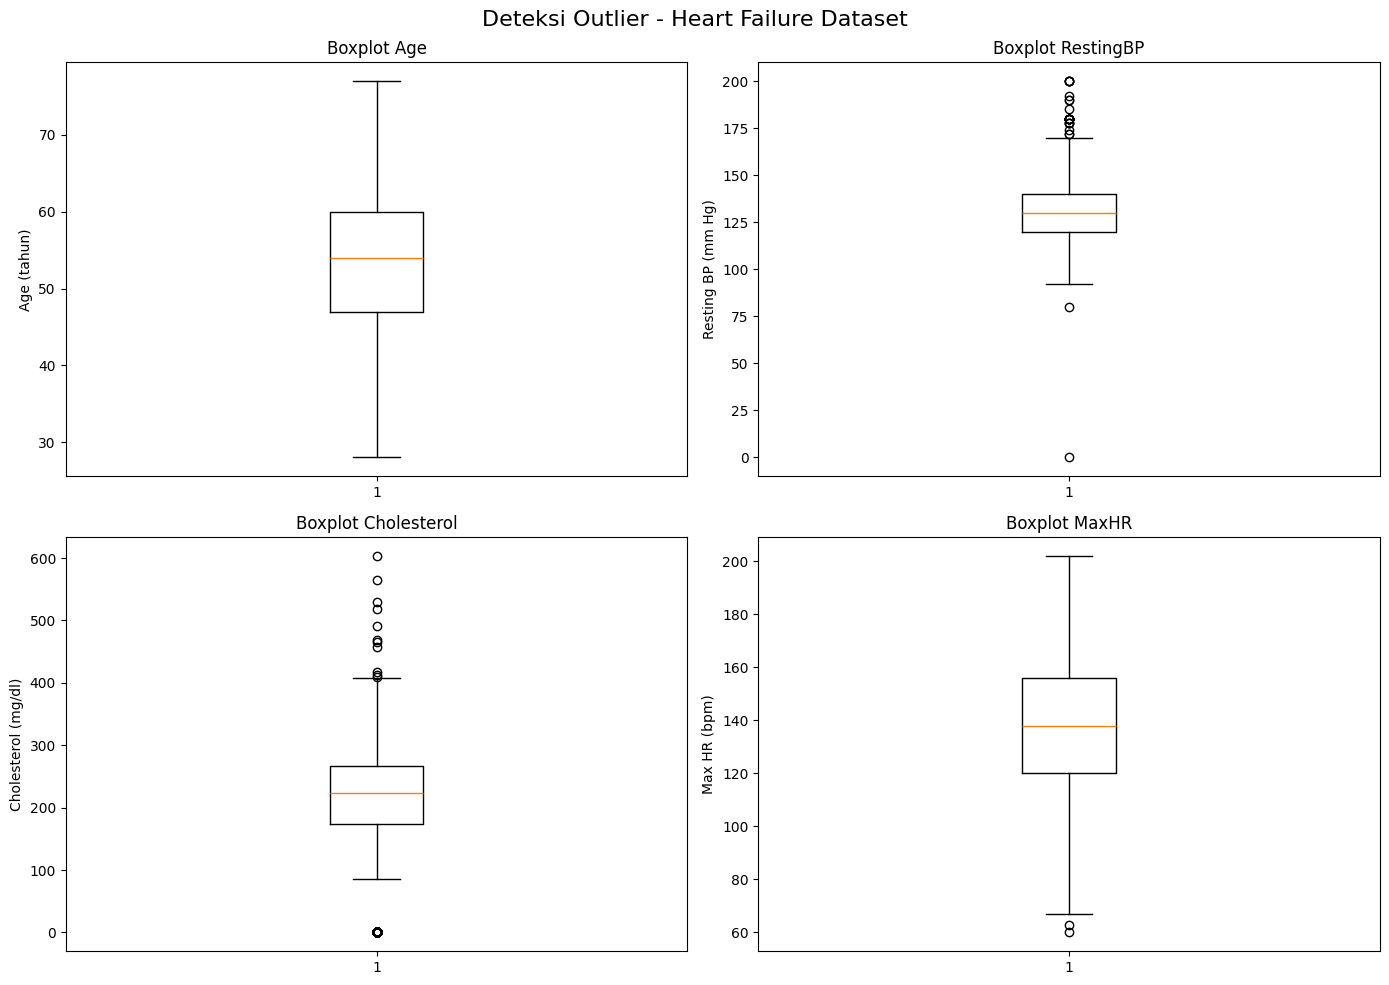

Visualisasi Boxplot Selesai & Gambar Disimpan


In [6]:
# Visualisasi Boxplot untuk deteksi outlier lebih lanjut
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Deteksi Outlier - Heart Failure Dataset', fontsize = 16)

# Boxplot Age
# Kotak = 50% data normal, titik diluar = outlier
axes[0,0].boxplot(df['Age'], vert = True)
axes[0,0].set_title('Boxplot Age')
axes[0,0].set_ylabel('Age (tahun)')

# Boxplot RestingBP
axes[0,1].boxplot(df['RestingBP'], vert = True)
axes[0,1].set_title('Boxplot RestingBP')
axes[0,1].set_ylabel('Resting BP (mm Hg)')

# Boxplot Cholesterol
axes[1,0].boxplot(df['Cholesterol'], vert = True)
axes[1,0].set_title('Boxplot Cholesterol')
axes[1,0].set_ylabel('Cholesterol (mg/dl)')

# Boxplot MaxHR
axes[1,1].boxplot(df['MaxHR'], vert = True)
axes[1,1].set_title('Boxplot MaxHR')
axes[1,1].set_ylabel('Max HR (bpm)')

plt.tight_layout()
plt.savefig('RawOutlier_Visualization.png')
plt.show()
print("Visualisasi Boxplot Selesai & Gambar Disimpan")

# 5. Data Preprocessing

In [7]:
# Menyalin Dataframe asli
df_clean = df.copy()
print(f"Data Awal : {df_clean.shape}")

Data Awal : (918, 12)


In [9]:
# Drop baris dengan nilai RestingBP = 0 (kemungkinan missing value)
df_clean = df_clean[df_clean['RestingBP'] > 0]
print(f"Baris RestingBP=0 Setelah Drop : {df_clean.shape}")

# Drop baris dengan nilai Cholesterol = 0 (kemungkinan missing value)
df_clean = df_clean[df_clean['Cholesterol'] > 0]
print(f"Baris Cholesterol=0 Setelah Drop : {df_clean.shape}")

# Drop baris yang memiliki nilai negatif pada Oldpeak
df_clean = df_clean[df_clean['Oldpeak'] >= 0]
print(f"Baris Oldpeak Negatif Setelah Drop : {df_clean.shape}")

# Drop baris dengan MaxHR yang tidak masuk akal (< 60 atau > 220)
df_clean = df_clean[(df_clean['MaxHR'] >= 60) & (df_clean['MaxHR'] <= 220)]
print(f"Baris MaxHR Ekstrem Setelah Drop : {df_clean.shape}")

# Drop Data Duplikat
df_clean = df_clean.drop_duplicates()
print(f"Setelah Drop Duplikat : {df_clean.shape}")
print("Data Cleaning Selesai")

Baris RestingBP=0 Setelah Drop : (917, 12)
Baris Cholesterol=0 Setelah Drop : (746, 12)
Baris Oldpeak Negatif Setelah Drop : (745, 12)
Baris MaxHR Ekstrem Setelah Drop : (745, 12)
Setelah Drop Duplikat : (745, 12)
Data Cleaning Selesai


In [10]:
# Encoding Fitur Kategorikal
le_dict = {}
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col + '_encoded'] = le.fit_transform(df_clean[col].astype(str))
    le_dict[col] = le
    
print("Contoh Hasil Encoding Fitur Kategorikal:")
print(df_clean[['Sex', 'Sex_encoded', 'ChestPainType', 'ChestPainType_encoded']].head())

Contoh Hasil Encoding Fitur Kategorikal:
  Sex  Sex_encoded ChestPainType  ChestPainType_encoded
0   M            1           ATA                      1
1   F            0           NAP                      2
2   M            1           ATA                      1
3   F            0           ASY                      0
4   M            1           NAP                      2


In [11]:
# FastingBS dan HeartDisease sudah dalam format numerik (0/1), tidak perlu encoding
print("Fitur yang sudah numerik:")
print(f"FastingBS unique values: {df_clean['FastingBS'].unique()}")
print(f"HeartDisease unique values: {df_clean['HeartDisease'].unique()}")
print(f"ExerciseAngina unique values: {df_clean['ExerciseAngina'].unique()}")

Fitur yang sudah numerik:
FastingBS unique values: [0 1]
HeartDisease unique values: [0 1]
ExerciseAngina unique values: ['N' 'Y']


In [12]:
# Normalisasi Fitur Numerik
# Tujuan : Menyamakan skala semua angka (mean 0, std 1)
# Alasan : Range Age (28-74) berbeda dengan RestingBP (95-200), dll
scaler = StandardScaler()
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
df_clean[num_cols] = scaler.fit_transform(df_clean[num_cols])

print("Data Setelah Normalisasi:")
print(df_clean[num_cols].describe().round(2))

Data Setelah Normalisasi:
          Age  RestingBP  Cholesterol   MaxHR  Oldpeak
count  745.00     745.00       745.00  745.00   745.00
mean     0.00       0.00         0.00    0.00    -0.00
std      1.00       1.00         1.00    1.00     1.00
min     -2.63      -2.37        -2.70   -2.90    -0.84
25%     -0.73      -0.75        -0.62   -0.74    -0.84
50%      0.12      -0.18        -0.13   -0.01    -0.38
75%      0.64       0.40         0.51    0.81     0.56
max      2.54       3.88         6.06    2.52     4.94


In [13]:
# Menyimpan Data Hasil Preprocessing
df_clean.to_csv('heartfailure_cleaned.csv', index = False)

print(f"Dataset Preprocessing berhasil disimpan!")
print(f"Shape Final : {df_clean.shape}")
print(f"\nKolom Final:")
print(df_clean.columns.tolist())
print(f"\nInfo Kolom yang Sudah Diproses:")
print(f"- Kolom Numerik Ternormalisasi: {['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']}")
print(f"- Kolom Kategorikal Terenkoding: {['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']}_encoded")

Dataset Preprocessing disimpan!
Shape Final : (745, 17)

 Kolom Final:
['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease', 'Sex_encoded', 'ChestPainType_encoded', 'RestingECG_encoded', 'ExerciseAngina_encoded', 'ST_Slope_encoded']
